### NeuralForecast Univariate/MultiVariate Models for predicting utilization

In [3]:
import pandas as pd

In [4]:
Y_df = pd.read_csv('data/gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [5]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [6]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [7]:
Y_df['y'] = Y_df['utilization_gpu_pct']

In [8]:
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [9]:
Y_ts = Y_df[['unique_id', 'ds', 'y']]

In [10]:
exog_vars = ['utilization_memory_pct', 'temperature_gpu', 'temperature_memory', 'power_draw_W']
X_ts = Y_df[['unique_id', 'ds'] + exog_vars]

In [11]:
X_ts['unique_id'] = X_ts.unique_id.astype(str)
X_ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   unique_id               1259185 non-null  object 
 1   ds                      1259185 non-null  int64  
 2   utilization_memory_pct  1259185 non-null  float64
 3   temperature_gpu         1259185 non-null  float64
 4   temperature_memory      1259185 non-null  float64
 5   power_draw_W            1259185 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 67.2+ MB


/tmp/ipykernel_7901/1014213204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ts['unique_id'] = X_ts.unique_id.astype(str)


In [12]:
Y_ts = Y_ts.merge(X_ts, on=['unique_id', 'ds'], how='left')

In [13]:
Y_ts.head()

,unique_id,ds,y,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
0,10217518336509_gpu0,0,6.360656,0.360656,65.180328,66.393443,54.939016
1,10217518336509_gpu0,1,0.435484,0.000000,40.000000,38.080645,46.433710
2,10217518336509_gpu0,2,0.031915,0.010638,63.638298,64.861702,53.556915
3,10217518336509_gpu0,3,0.063830,0.021277,40.000000,38.042553,46.569681
4,10217518336509_gpu0,4,1.150538,0.032258,62.311828,63.387097,52.611935


In [14]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
train_df = Y_df.groupby('unique_id').head(-h)
test_df = Y_df.groupby('unique_id').tail(h)
#validation
train_df = Y_df.groupby('unique_id').head(-h)
validation_df = Y_df.groupby('unique_id').tail(h)

print(f"Training set size: {len(train_df)}")
print(f"validation set size: {len(validation_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 1246765
validation set size: 12420
Test set size: 12420


In [15]:
import logging

import torch
from neuralforecast.core import NeuralForecast
from neuralforecast.models import TSMixer, TSMixerx, NHITS, MLPMultivariate
from neuralforecast.losses.pytorch import MAE

In [16]:
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
torch.set_float32_matmul_precision('high')

In [17]:
horizon = 30
input_size = 32
models = [
          TSMixer(h=horizon,
                input_size=input_size,
                n_series=414,
                max_steps=100,
                val_check_steps=50,
                early_stop_patience_steps=5,
                scaler_type='identity',
                valid_loss=MAE(),
                random_seed=12345678,
                devices=1,
                accelerator='cpu',
                strategy='auto',
                batch_size=8,
                precision='bf16-mixed'
                ),  
          TSMixerx(h=horizon,
                input_size=input_size,
                n_series=414,
                max_steps=100,
                val_check_steps=50,
                early_stop_patience_steps=5,
                scaler_type='identity',
                dropout=0.7,
                valid_loss=MAE(),
                random_seed=12345678,
                futr_exog_list=['utilization_memory_pct', 'temperature_gpu', 'temperature_memory', 'power_draw_W'],
                devices=1,
                accelerator='cpu',
                strategy='auto',
                batch_size=8,
                precision='bf16-mixed'
                ),
          MLPMultivariate(h=horizon,
                input_size=input_size,
                n_series=414,
                max_steps=100,
                val_check_steps=50,
                early_stop_patience_steps=5,
                scaler_type='standard',
                hidden_size=256,
                valid_loss=MAE(),
                random_seed=12345678,
                devices=1,
                        accelerator='cpu',
                strategy='auto',
                batch_size=8,
                precision='bf16-mixed'
                ),                                             
           NHITS(h=horizon,
                input_size=horizon,
                max_steps=100,
                val_check_steps=50,
                early_stop_patience_steps=5,
                scaler_type='robust',
                valid_loss=MAE(),
                random_seed=12345678,
                devices=1,
                accelerator='cpu',
                strategy='auto',
                batch_size=8,
                precision='bf16-mixed'
                ),                                                                       
         ]

[rank: 0] Seed set to 12345678
[rank: 0] Seed set to 12345678
[rank: 0] Seed set to 12345678
[rank: 0] Seed set to 12345678


In [18]:
Y_ts.head()

,unique_id,ds,y,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
0,10217518336509_gpu0,0,6.360656,0.360656,65.180328,66.393443,54.939016
1,10217518336509_gpu0,1,0.435484,0.000000,40.000000,38.080645,46.433710
2,10217518336509_gpu0,2,0.031915,0.010638,63.638298,64.861702,53.556915
3,10217518336509_gpu0,3,0.063830,0.021277,40.000000,38.042553,46.569681
4,10217518336509_gpu0,4,1.150538,0.032258,62.311828,63.387097,52.611935


In [19]:
# pick a reference start time
start_time = pd.Timestamp("2023-01-01 00:00:00")

# convert ds (integer steps) into datetime
Y_ts['ds'] = pd.to_timedelta(Y_ts['ds'] * 10, unit='s') + start_time

In [20]:
nf = NeuralForecast(
    models=models,
    freq="10s",
)


In [21]:
Y_ts.unique_id.nunique()

414

In [23]:
H=30

In [24]:
df_test =Y_ts.groupby('unique_id').tail(H)
df_train = Y_ts.drop(df_test.index)

In [25]:
nf.fit(df=df_train, val_size=30)

2025-08-24 23:50:45.104177: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-24 23:50:49.166864: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-24 23:50:51.440427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756072251.966868    7901 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756072252.216056    7901 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756072253.623684    7901 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [31]:
X_ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   unique_id               1259185 non-null  object 
 1   ds                      1259185 non-null  int64  
 2   utilization_memory_pct  1259185 non-null  float64
 3   temperature_gpu         1259185 non-null  float64
 4   temperature_memory      1259185 non-null  float64
 5   power_draw_W            1259185 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 67.2+ MB


In [32]:
# pick a reference start time
start_time = pd.Timestamp("2023-01-01 00:00:00")

# convert ds (integer steps) into datetime
X_ts['ds'] = pd.to_timedelta(X_ts['ds'] * 10, unit='s') + start_time

/tmp/ipykernel_7901/731354203.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ts['ds'] = pd.to_timedelta(X_ts['ds'] * 10, unit='s') + start_time


In [33]:
fcst_df = nf.predict(futr_df=X_ts)
fcst_df.columns = fcst_df.columns.str.replace('-median', '')
fcst_df.head()

/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/neuralforecast/core.py:939: UserWarning: Dropped 1,246,765 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,TSMixer,TSMixerx,MLPMultivariate,NHITS
0,10217518336509_gpu0,2023-01-01 14:01:20,94.767807,94.929657,94.782036,94.737885
1,10217518336509_gpu0,2023-01-01 14:01:30,94.575714,94.906860,94.831917,94.822495
2,10217518336509_gpu0,2023-01-01 14:01:40,94.625633,94.936859,94.765259,94.887314
3,10217518336509_gpu0,2023-01-01 14:01:50,94.614342,94.935661,94.788193,94.890724
4,10217518336509_gpu0,2023-01-01 14:02:00,94.896614,94.930862,94.769875,94.956573


In [34]:
from utilsforecast.plotting import plot_series

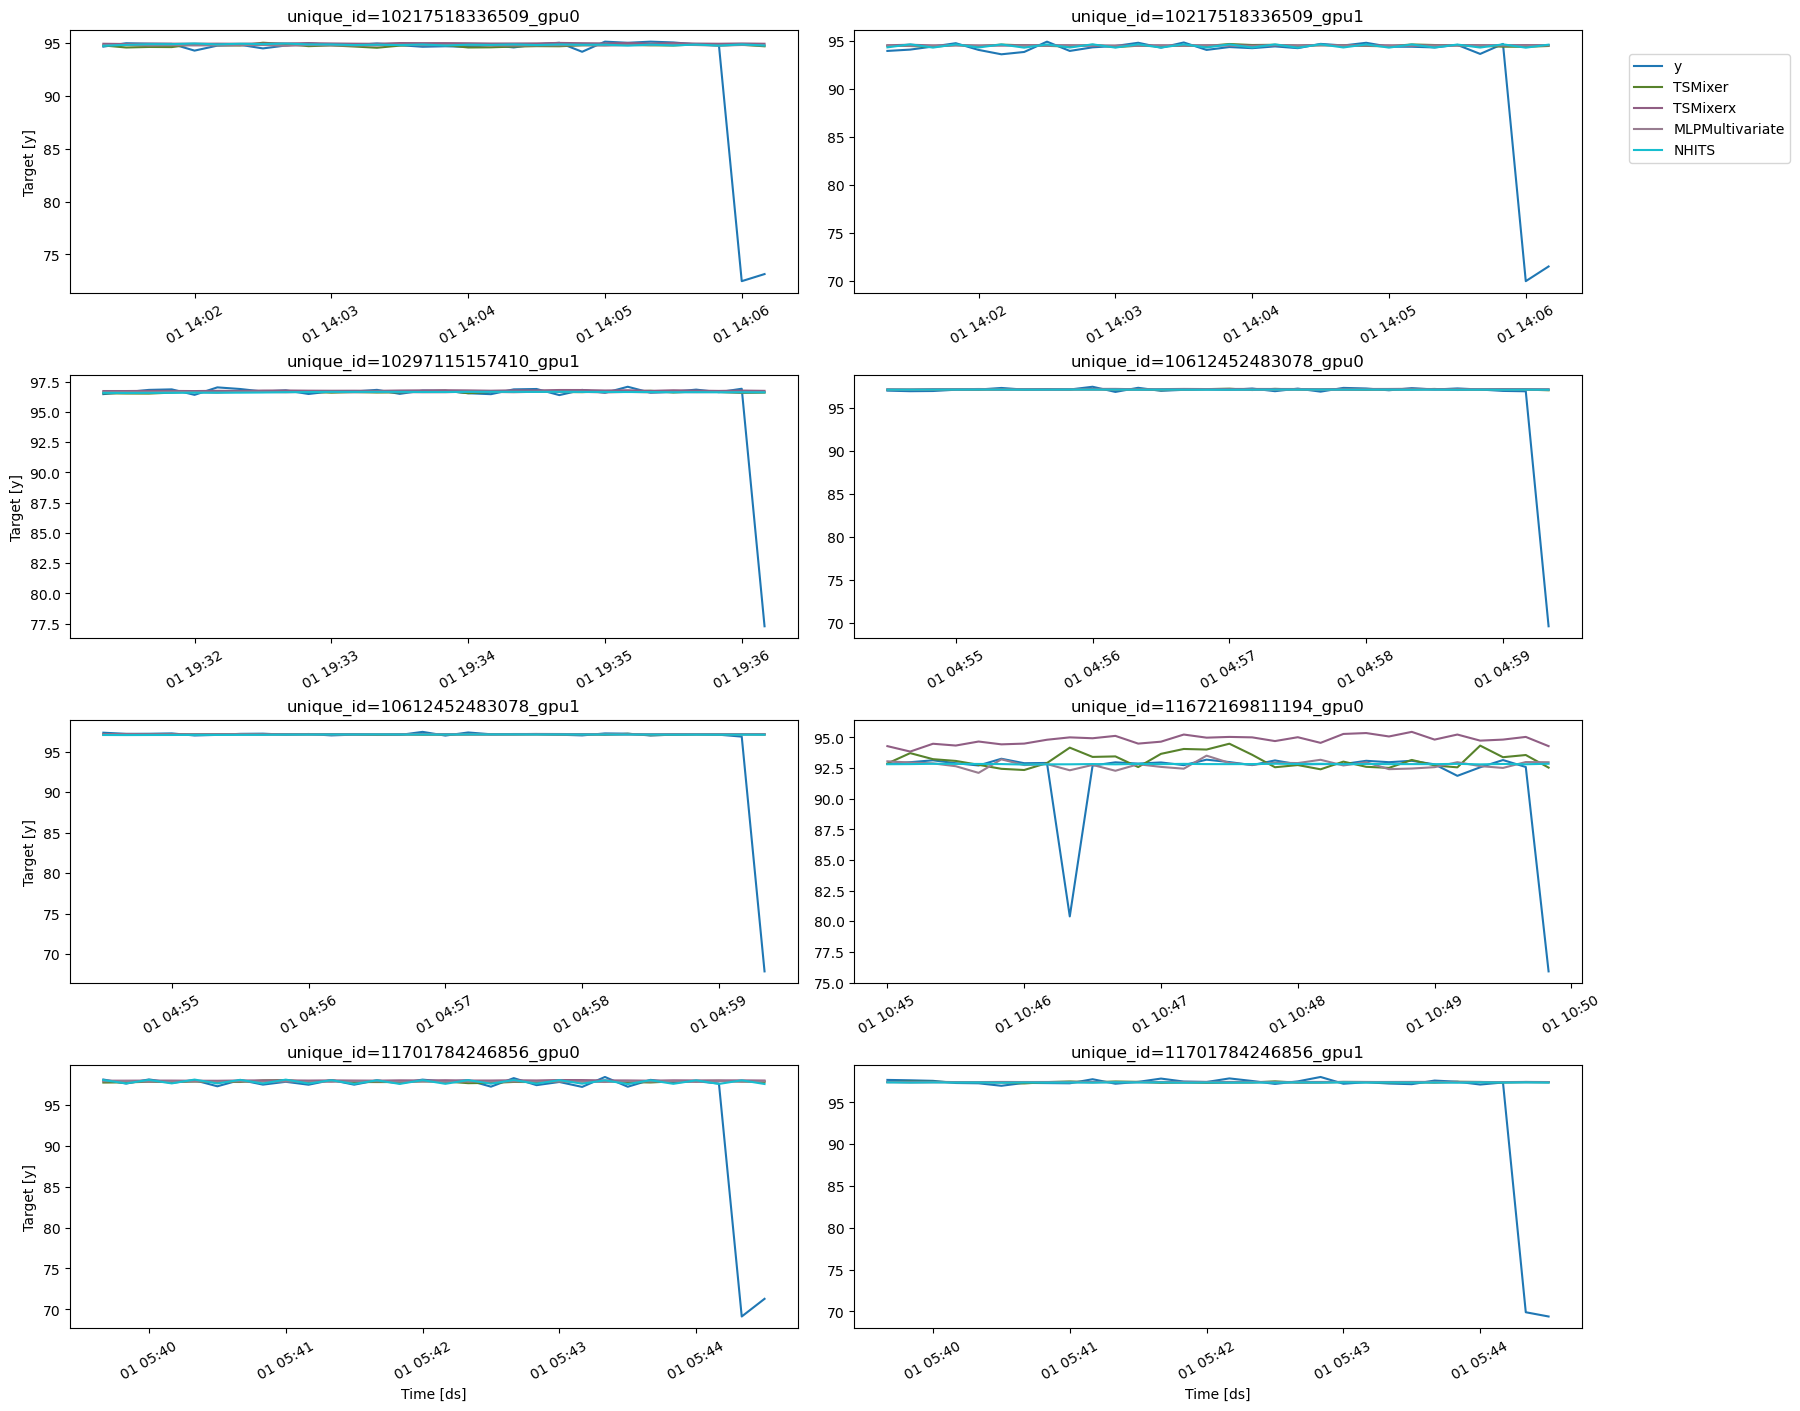

In [35]:
plot_series(Y_ts, fcst_df, plot_random=False, max_insample_length=15*2)

In [43]:
import polars as pl
import pandas as pd
import numpy as np
from utilsforecast.losses import mae, rmse, mse, mape, smape

def evaluate_forecast(df, y_col="y", id_col="unique_id", ds_col="ds"):
    # Detect all forecast model columns (exclude id, ds, y)
    model_cols = [c for c in df.columns if c not in [id_col, ds_col, y_col, "Unnamed: 0"]]
    
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, y_col] + model_cols])
    
    # -----------------
    # Per-series metrics
    # -----------------
    results = {
        "MAE": mae(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
    }
    
    metrics_df = None
    for name, metric in results.items():
        metric = metric.rename({c: f"{c}_{name}" for c in metric.columns if c != id_col})
        metrics_df = metric if metrics_df is None else metrics_df.join(metric, on=id_col, how="inner")
    per_series_metrics = metrics_df.to_pandas()
    
    # -----------------
    # Global metrics
    # -----------------
    global_results = []
    y_true = df[y_col].values
    
    for model in model_cols:
        y_pred = df[model].values
        global_results.append({
            "Model": model,
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MSE": np.mean((y_true - y_pred) ** 2),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            "sMAPE": np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))),
            "wMAPE": np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        })
    
    global_metrics = pd.DataFrame(global_results)
    
    return per_series_metrics, global_metrics

# Example usage
per_series_metrics, global_metrics = evaluate_forecast(fcst_df_1)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)


Per-series metrics:
              unique_id  TSMixer_MAE  TSMixerx_MAE  MLPMultivariate_MAE  \
0  10217518336509_gpu0     1.675989      1.661759             1.625925   
1  10217518336509_gpu1     1.877130      1.879876             1.873238   
2  10297115157410_gpu1     0.801651      0.797929             0.803148   
3  10612452483078_gpu0     1.039406      1.046626             1.032778   
4  10612452483078_gpu1     1.068276      1.070439             1.067168   

   NHITS_MAE  TSMixer_RMSE  TSMixerx_RMSE  MLPMultivariate_RMSE  NHITS_RMSE  \
0   1.631864      5.677094       5.723124              5.682416    5.688624   
1   1.806232      6.135485       6.170701              6.158642    6.136911   
2   0.808913      3.533150       3.558776              3.542969    3.537162   
3   1.033023      5.012744       5.034931              5.023604    5.024311   
4   1.076578      5.335968       5.342715              5.339313    5.331508   

   TSMixer_MSE  ...  MLPMultivariate_MSE  NHITS_MSE  TSMixe

/tmp/ipykernel_7901/2603613953.py:43: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


In [ ]:
2.034584  
8.022793  
64.365206   
2.653182  
2.176165

In [41]:
fcst_df_1.head()

,unique_id,ds,TSMixer,TSMixerx,MLPMultivariate,NHITS,y
0,10217518336509_gpu0,2023-01-01 14:01:20,94.767807,94.929657,94.782036,94.737885,94.655914
1,10217518336509_gpu0,2023-01-01 14:01:30,94.575714,94.906860,94.831917,94.822495,94.978723
2,10217518336509_gpu0,2023-01-01 14:01:40,94.625633,94.936859,94.765259,94.887314,94.935484
3,10217518336509_gpu0,2023-01-01 14:01:50,94.614342,94.935661,94.788193,94.890724,94.914894
4,10217518336509_gpu0,2023-01-01 14:02:00,94.896614,94.930862,94.769875,94.956573,94.279570


In [40]:
fcst_df_1 = fcst_df.merge(df_test[['unique_id', 'ds','y']], on=['unique_id', 'ds'], how='left')

In [ ]:
fcst_d = 